<a href="https://colab.research.google.com/github/vidhu-psit/MachineLearningPortfolio/blob/master/Hierarchichal/HierarchichalClustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from IPython.display import Image
Image(url='https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/015/038/original/hierarch.gif?1663699414')

In [2]:
!gdown 1XNQvD8RtK49KNIR7VK9nkmb6tTPNXwVu

Downloading...
From: https://drive.google.com/uc?id=1XNQvD8RtK49KNIR7VK9nkmb6tTPNXwVu
To: /content/Cust_Spend_Data.csv
100% 266/266 [00:00<00:00, 837kB/s]


##H Clustering
- K need not to be guessed
- It is hardly used
- If Data is more than 1000 rows, Dendogram can get very clumsy and it becomes impossible to identify cluters


#Perform Clustering using Hierarchichal clustering

In [4]:
import pandas as pd
custData = pd.read_csv("Cust_Spend_Data.csv")
custData.head(10)

,Cust_ID,Name,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items
0,1,A,10000,2,1,1,0
1,2,B,7000,3,0,10,9
2,3,C,7000,7,1,3,4
3,4,D,6500,5,1,1,4
4,5,E,6000,6,0,12,3
5,6,F,4000,3,0,1,8
6,7,G,2500,5,0,11,2
7,8,H,2500,3,0,1,1
8,9,I,2000,2,0,2,2
9,10,J,1000,4,0,1,7


In [5]:
custData.shape

(10, 7)

In [6]:
#Remove ID and name col
custData_clean = custData.iloc[:,2:]
custData_clean.head(10)

,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items
0,10000,2,1,1,0
1,7000,3,0,10,9
2,7000,7,1,3,4
3,6500,5,1,1,4
4,6000,6,0,12,3
5,4000,3,0,1,8
6,2500,5,0,11,2
7,2500,3,0,1,1
8,2000,2,0,2,2
9,1000,4,0,1,7


In [9]:
from sklearn.preprocessing import StandardScaler
std_sclr = StandardScaler()
custData_scld = pd.DataFrame(std_sclr.fit_transform(custData_clean), columns=custData_clean.columns)
custData_scld

,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items
0,1.886498,-1.240347,1.527525,-0.741433,-1.380131
1,0.787567,-0.620174,-0.654654,1.280656,1.725164
2,0.787567,1.860521,1.527525,-0.292080,0.000000
3,0.604412,0.620174,1.527525,-0.741433,0.000000
4,0.421257,1.240347,-0.654654,1.730009,-0.345033
5,-0.311364,-0.620174,-0.654654,-0.741433,1.380131
6,-0.860829,0.620174,-0.654654,1.505333,-0.690066
7,-0.860829,-0.620174,-0.654654,-0.741433,-1.035098
8,-1.043984,-1.240347,-0.654654,-0.516756,-0.690066
9,-1.410294,0.000000,-0.654654,-0.741433,1.035098


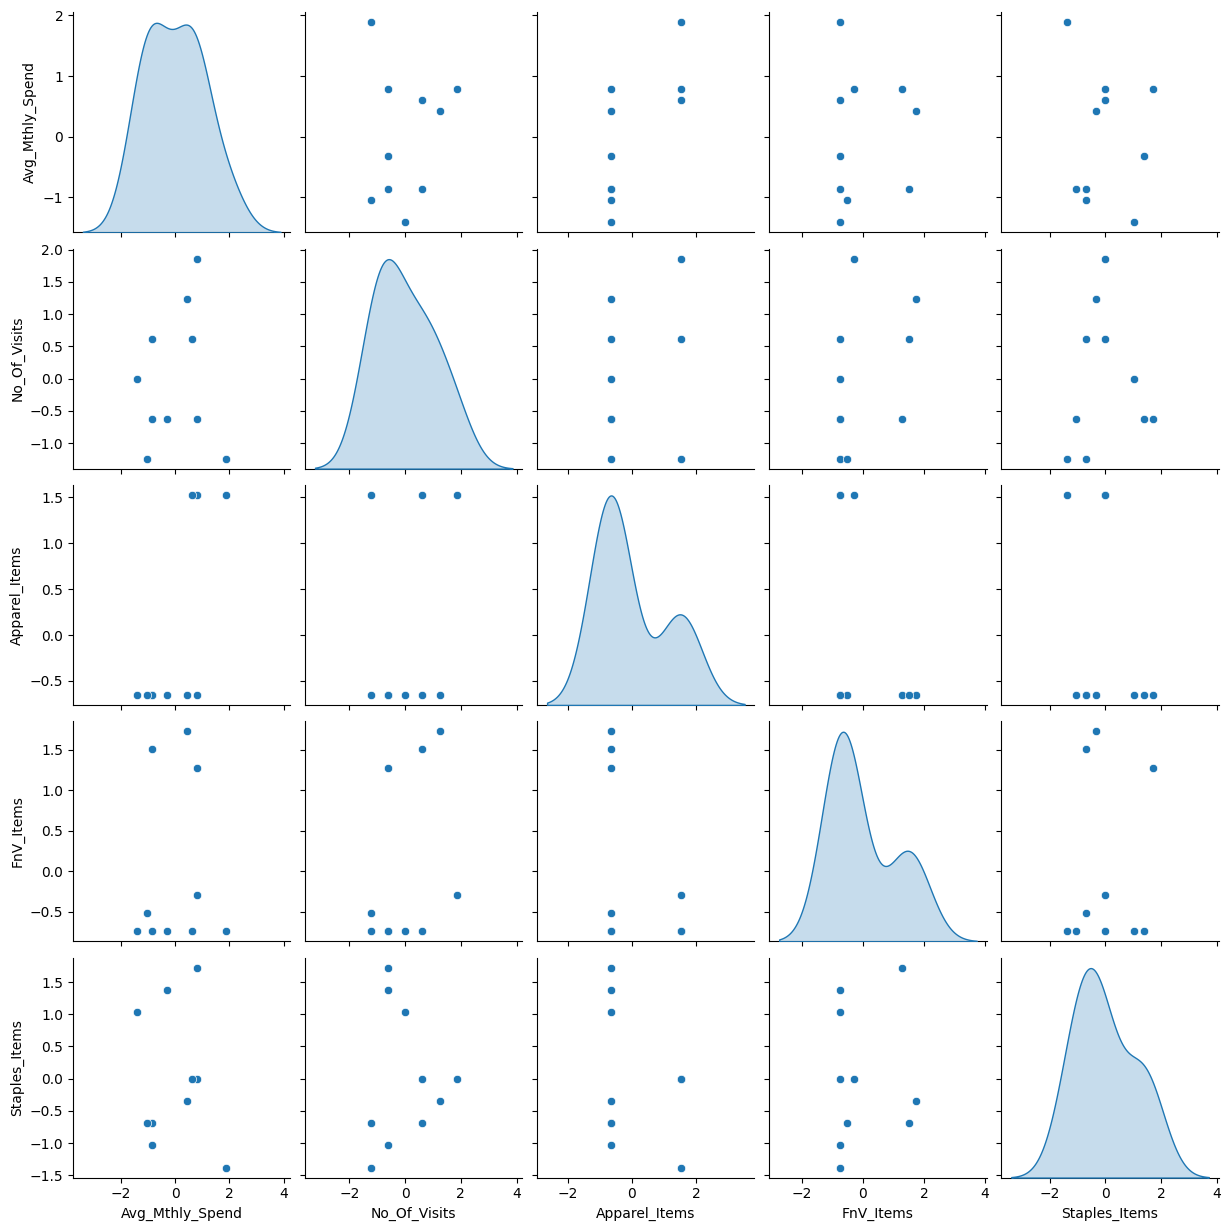

In [11]:
import seaborn as sns
sns.pairplot(custData_scld, diag_kind='kde')

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [14]:
from numpy import average
z = linkage(custData_scld, metric='euclidean', method='average')

In [17]:
z.shape

(9, 4)

In [15]:
z

array([[ 7.        ,  8.        ,  0.76660834,  2.        ],
       [ 5.        ,  9.        ,  1.30817103,  2.        ],
       [ 2.        ,  3.        ,  1.33188797,  2.        ],
       [ 4.        ,  6.        ,  1.48252699,  2.        ],
       [10.        , 11.        ,  2.29187962,  4.        ],
       [ 1.        , 13.        ,  3.01368978,  3.        ],
       [ 0.        , 12.        ,  3.12171991,  3.        ],
       [14.        , 15.        ,  3.23053961,  7.        ],
       [16.        , 17.        ,  3.78685213, 10.        ]])

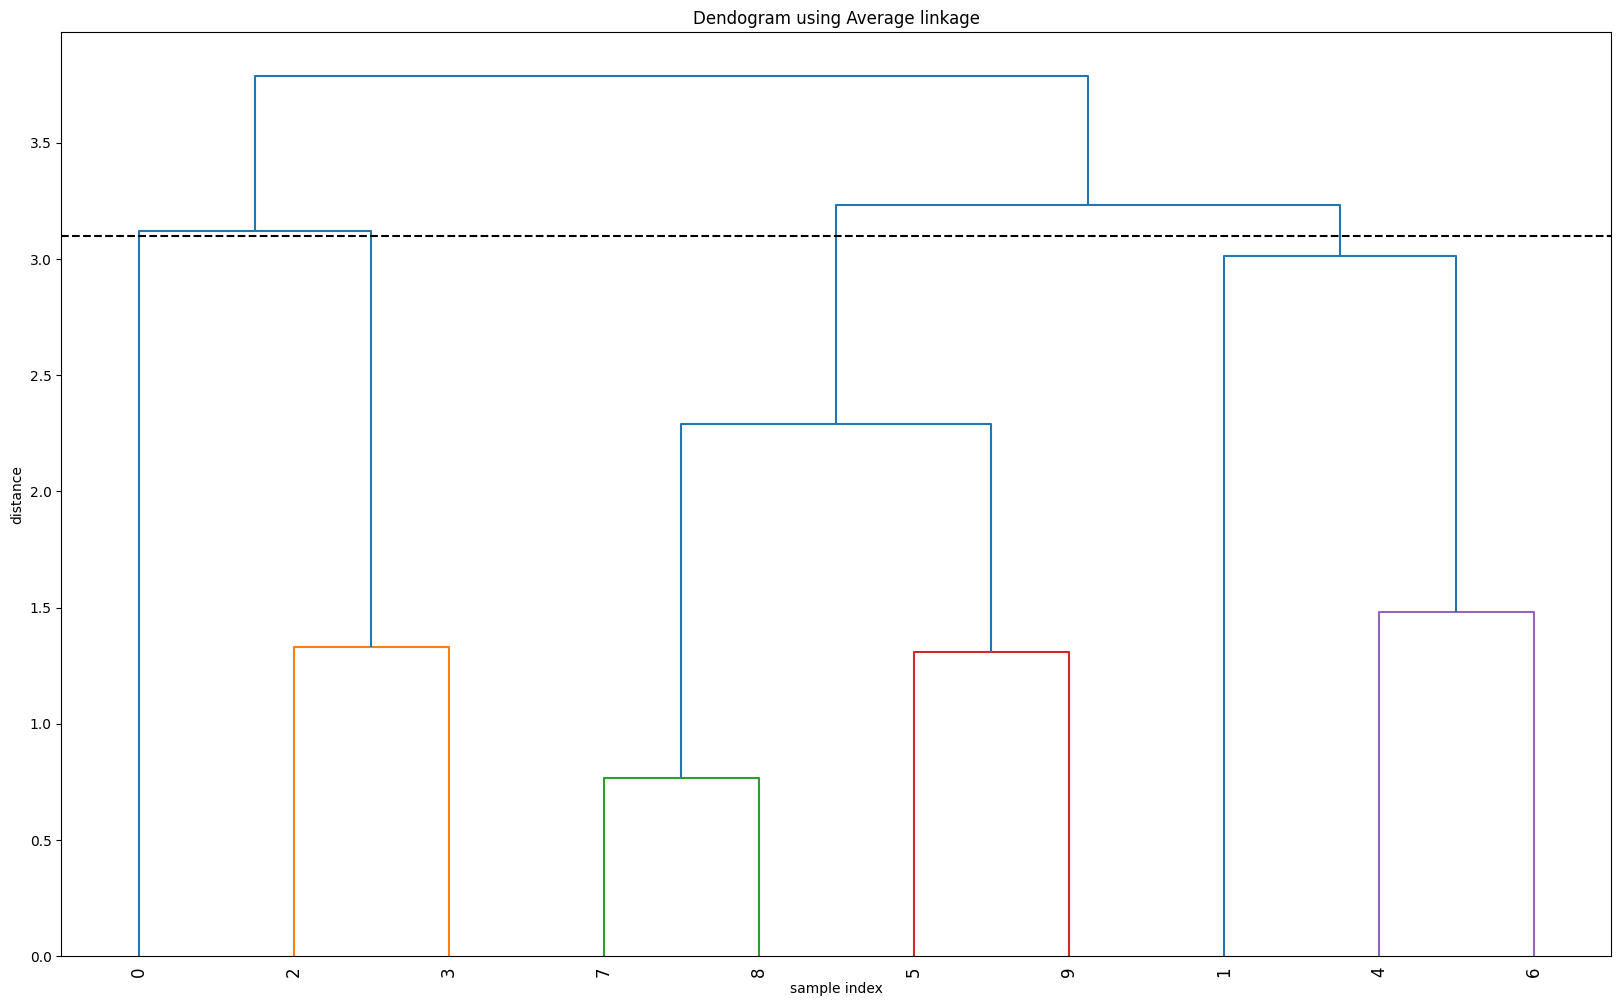

In [21]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(20,12))
dendrogram(z, labels=custData_scld.index, ax=ax, color_threshold=2)
plt.xticks(rotation=90)

ax.set_ylabel('distance')
ax.set_xlabel('sample index')
ax.set_title('Dendogram using Average linkage')
plt.axhline(y=3.1, color='k', linestyle='--')

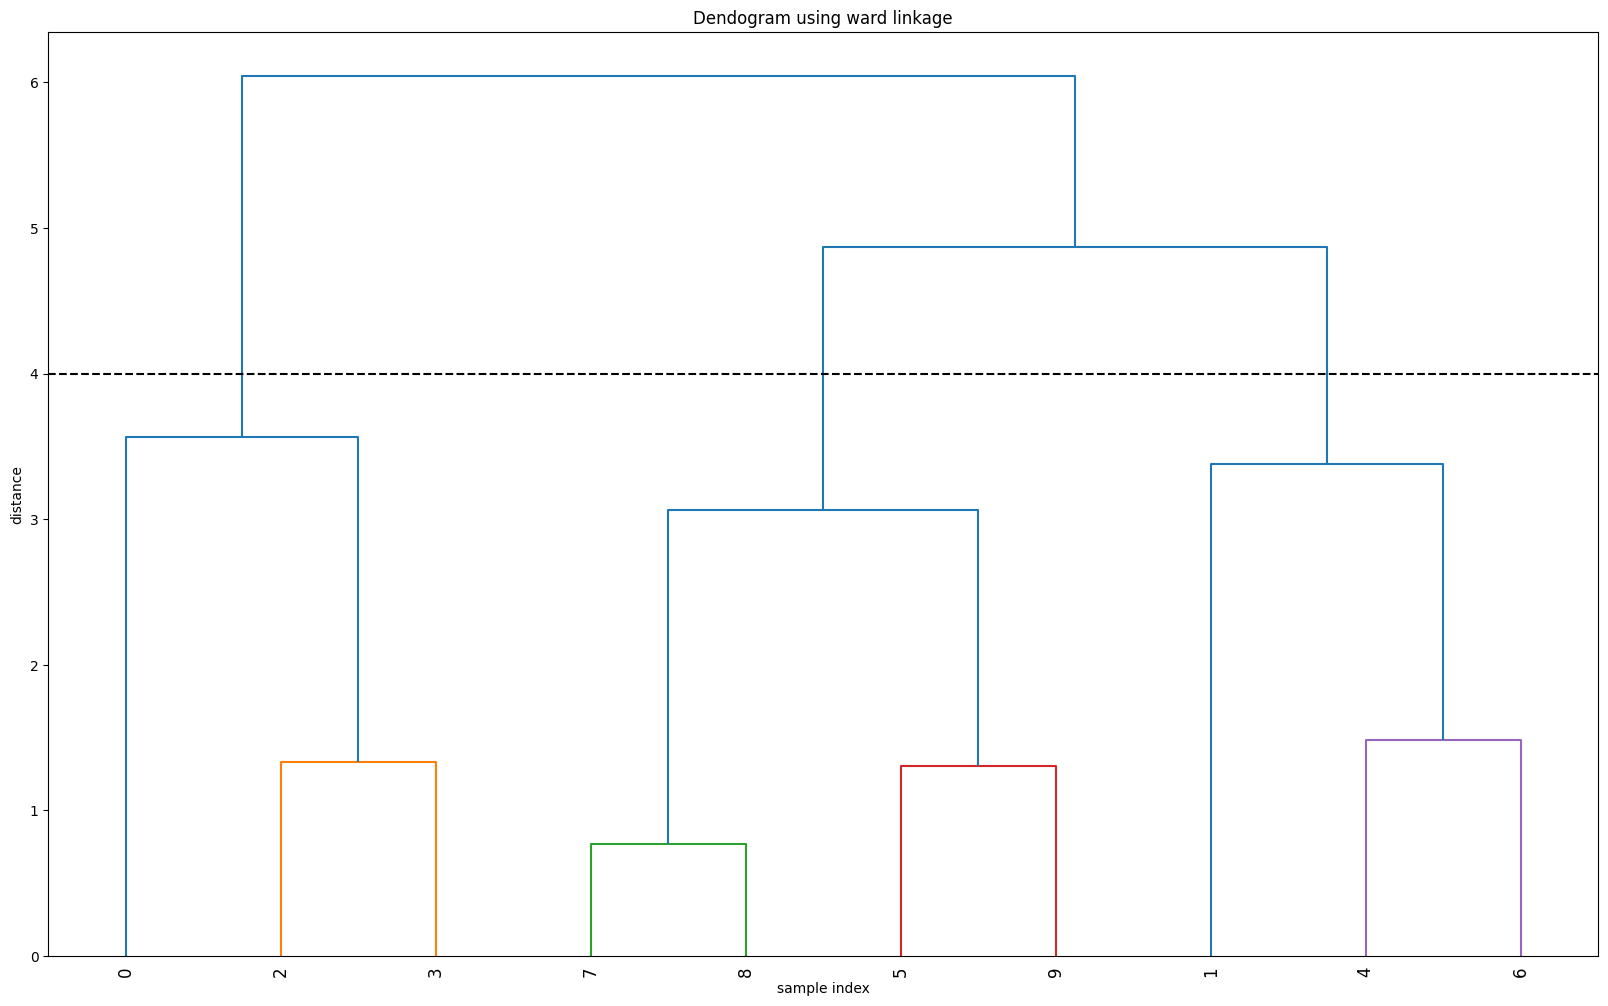

In [25]:

z_ward = linkage(custData_scld, metric='euclidean', method='ward')

fig, ax = plt.subplots(figsize=(20,12))
dendrogram(z_ward, labels=custData_scld.index, ax=ax, color_threshold=2)
plt.xticks(rotation=90)

ax.set_ylabel('distance')
ax.set_xlabel('sample index')
ax.set_title('Dendogram using ward linkage')
plt.axhline(y=4, color='k', linestyle='--')

In [26]:
z_ward

array([[ 7.        ,  8.        ,  0.76660834,  2.        ],
       [ 5.        ,  9.        ,  1.30817103,  2.        ],
       [ 2.        ,  3.        ,  1.33188797,  2.        ],
       [ 4.        ,  6.        ,  1.48252699,  2.        ],
       [10.        , 11.        ,  3.06311476,  4.        ],
       [ 1.        , 13.        ,  3.37874675,  3.        ],
       [ 0.        , 12.        ,  3.56396731,  3.        ],
       [14.        , 15.        ,  4.86954587,  7.        ],
       [16.        , 17.        ,  6.04286743, 10.        ]])

- 1 clucster is row 7 and 8 -->10
- 2 clucster is row 5 and 9 -->11
- 3 clucster is row 2 and 3 -->12
- 4 clucster is row 4 and 6 -->13
- 5 clucster is row 10 and 11 -->14
- 6 clucster is row 1 and 13 -->15
- 7 clucster is row 0 and 12 -->16
- 8 clucster is row 14 and 15 -->17
- 9 clucster is row 16 and 17 -->18
for 10 rows, total 9 cluster
linkage matrix shaper is (n-1,4) for n data points



In [28]:
#K value is 3
#use sklearn AgglomerativeClustering for final labels
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=3, linkage='ward')

In [29]:
model.fit(custData_scld)

AgglomerativeClustering(n_clusters=3)

In [31]:
custData_clean["labels"] = model.labels_
custData_clean.head(10)

,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items,labels
0,10000,2,1,1,0,0
1,7000,3,0,10,9,1
2,7000,7,1,3,4,0
3,6500,5,1,1,4,0
4,6000,6,0,12,3,1
5,4000,3,0,1,8,2
6,2500,5,0,11,2,1
7,2500,3,0,1,1,2
8,2000,2,0,2,2,2
9,1000,4,0,1,7,2


In [34]:
# analysis of clusters formed
h_clusters_mthly_spend = 	pd.DataFrame(custData_clean.groupby(["labels"]).Avg_Mthly_Spend.mean())
h_clusters_num_of_visits = 	pd.DataFrame(custData_clean.groupby(["labels"]).No_Of_Visits.mean())
h_clusters_apparel_items = 	pd.DataFrame(custData_clean.groupby(["labels"]).Apparel_Items.mean())
h_clusters_fnv_items = 	pd.DataFrame(custData_clean.groupby(["labels"]).FnV_Items.mean())
h_clusters_staples_items = 	pd.DataFrame(custData_clean.groupby(["labels"]).Staples_Items.mean())

In [35]:
df = pd.concat([pd.Series([0,1,2]), h_clusters_mthly_spend, h_clusters_num_of_visits, h_clusters_apparel_items,h_clusters_fnv_items, h_clusters_staples_items ], axis=1)
df.columns = ["Cluster_id","Avg_Mthly_Spend","No_Of_Visits" ,"Apparel_Items", "FnV_Items", "Staples_Items"]
df.head()

,Cluster_id,Avg_Mthly_Spend,No_Of_Visits,Apparel_Items,FnV_Items,Staples_Items
0,0,7833.333333,4.666667,1.0,1.666667,2.666667
1,1,5166.666667,4.666667,0.0,11.000000,4.666667
2,2,2375.000000,3.000000,0.0,1.250000,4.500000


<Axes: xlabel='Cluster_id', ylabel='Avg_Mthly_Spend'>

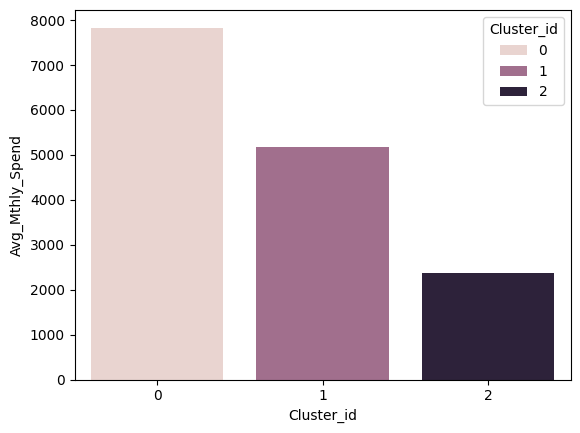

In [36]:
sns.barplot(x=df.Cluster_id, y=df.Avg_Mthly_Spend, hue=df.Cluster_id)

<Axes: xlabel='Cluster_id', ylabel='No_Of_Visits'>

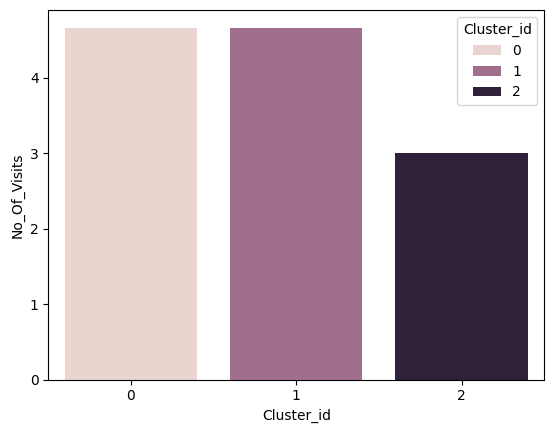

In [37]:
sns.barplot(x=df.Cluster_id, y=df.No_Of_Visits, hue=df.Cluster_id)

<Axes: xlabel='Cluster_id', ylabel='Apparel_Items'>

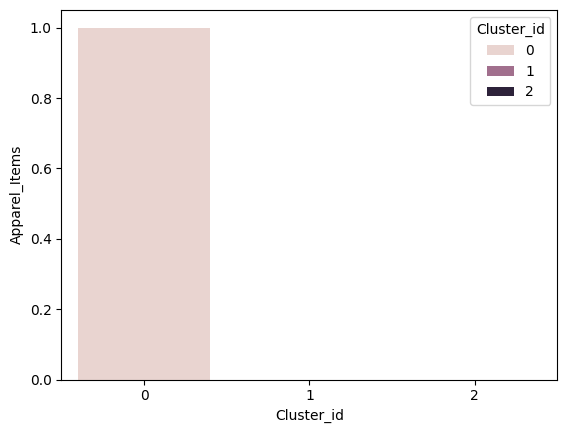

In [38]:
sns.barplot(x=df.Cluster_id, y=df.Apparel_Items, hue=df.Cluster_id)

<Axes: xlabel='Cluster_id', ylabel='FnV_Items'>

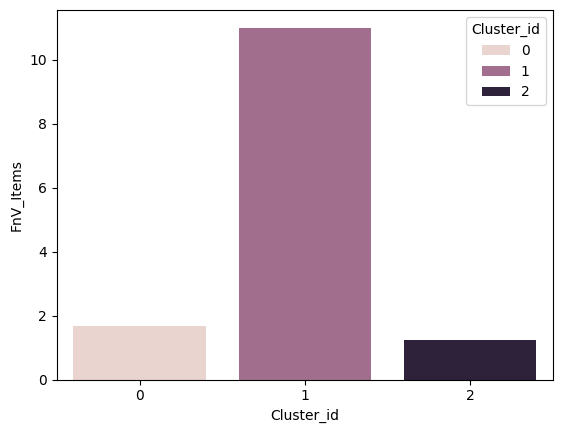

In [39]:
sns.barplot(x=df.Cluster_id, y=df.FnV_Items, hue=df.Cluster_id)

<Axes: xlabel='Cluster_id', ylabel='Staples_Items'>

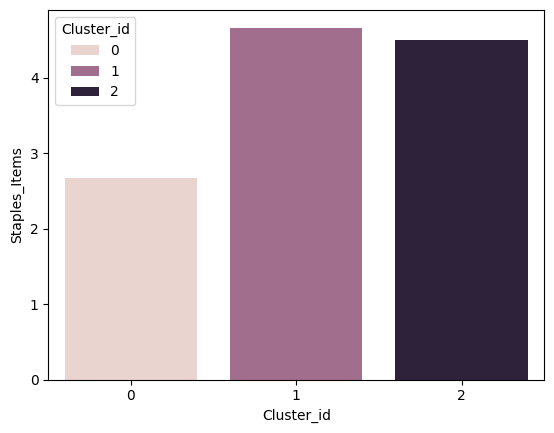

In [40]:
sns.barplot(x=df.Cluster_id, y=df.Staples_Items, hue=df.Cluster_id)

Below are the insight that we can make out after analysing the above bar plots:
1. Customers in cluster 0 has the highest avg monthly spend, they frequently visit the store, they tend to prefer more apperal items and very lesser FnV and staple items.We can target these customer more apperal related ads.
2. Customers in cluster 1 has the second highest avg monthly spend, with highest number of visits to the store, they tend to buy more of FnV and staple items and almost no apperal items.We can target these customer more FnV and staple items related ads.
3. Customers in cluster 2 has the least avg monthly spend, with lesser number of visits to the store, they tend to buy more staple items and less of FnV items and almost no apperal items.We can target these customer more FnV and staple items related ads where top priorty goes to staple items.